## Lecture 5: Parallel Computing 2 — Granularity, Load Balancing & Map-Filter-Reduce

### ****Milestone 1:** Chunked Mandelbrot (20 min)**

****Goal:** Decouple the number of chunks from the number of workers.**

In [11]:
from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    """Computes the escape iteration count for a single point in the mandelbrot set.
    
    Parameters
    ----------
    c_real : float 
        The real part of the complex coordinate to test in the Mandelbrot iteration.
    c_imag: float
        The imaginary part of the complex coordinate to test in the Mandelbrot iteration.
    max_iter : int
        Maximum number of iterations to perform.
    
    Returns
    -------
    int
        Number of iterations computed. 
    """
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    """Compute the mandelbrot set for a single chunk.

    Parameters
    ----------
    row_start : int
        The starting index of the chunk.
    row_end : int
        The end index of the chunk.
    N : int
        The chunks width. Should match the image width.
    x_min : float
        Minimum x-value (left boundary) of the complex plane.
    x_max : float
        Maximum x-value (right boundary) of the complex plane.
    y_min : float
        Minimum y-value (bottom boundary) of the complex plane.
    y_max : float
        Maximum y-value (top boundary) of the complex plane.
    max_iter : int
        Maximum number of iterations per pixel.
    
    Returns
    -------
    NDArray[int]
        A numpy matrix (height x width) with iteration counts per pixel.
    """
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def _worker(args): 
    return mandelbrot_chunk(*args) # plain Python, must be module-level

In [12]:
# From slide 27

# Extend your L04 mandelbrot parallel to (include n chunks):
def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4, n_chunks=None):
    """Compute the mandelbrot set in parallel using chunks.

    Parameters
    ----------
    N : int
        The pixel width and height.
    x_min : float
        Minimum x-value (left boundary) of the complex plane.
    x_max : float
        Maximum x-value (right boundary) of the complex plane.
    y_min : float
        Minimum y-value (bottom boundary) of the complex plane.
    y_max : float
        Maximum y-value (top boundary) of the complex plane.
    max_iter : int
        Maximum number of iterations per pixel.
    n_workers : int, optional
        Number of parallel processes to compute chunks with.
    n_chunks: 
        Number of chunks. Defaults to N / 4.
    
    Returns
    -------
    NDArray[int]
        A numpy matrix (height x width) with iteration counts per pixel.
    """
    if n_chunks is None:
        n_chunks = n_workers
    chunk_size = max(1, N // n_chunks)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    tiny = [(0, 8, 8, x_min, x_max, y_min, y_max, max_iter)]
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

****What to do:****

- **Add an `n_chunks` parameter to `mandelbrot_parallel` (default: `n_chunks = n_workers`)**

Done. Please see the code above.

- **Verify output still matches the serial result from L04**

In [13]:
# This is a copy from lecture 4, but with updated function names


# From slide 45 (The updated once)

# mandelbrot_parallel.py (Tasks 1-3 are one continuous script)
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path

@njit
def mandelbrot_pixel_l04(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit
def mandelbrot_chunk_l04(row_start, row_end, N,
                     x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel_l04(x_min + col*dx, c_imag, max_iter)
    return out

def mandelbrot_serial_l04(N, x_min, x_max, y_min, y_max, max_iter=100):
    return mandelbrot_chunk_l04(0, N, N, x_min, x_max, y_min, y_max, max_iter)

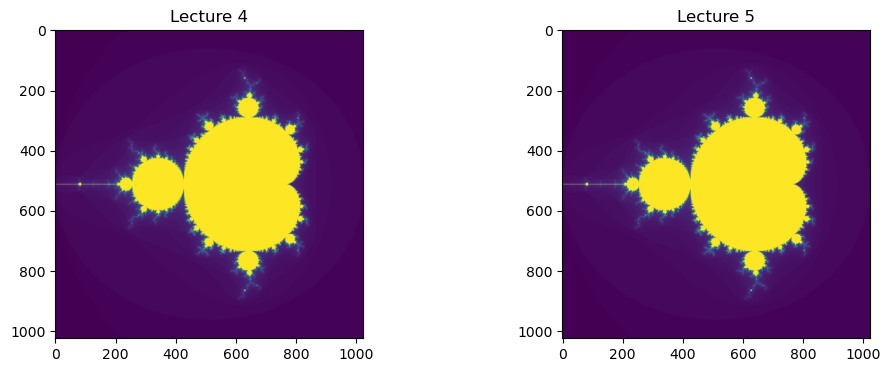

In [14]:
l04_image = mandelbrot_serial_l04(1024, -2, 1, -1.5, 1.5, 100)
l05_image = mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=os.cpu_count()//2)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(l04_image)
axes[0].set_title("Lecture 4")
axes[1].imshow(l05_image)
axes[1].set_title("Lecture 5")
plt.show()

They appear the same.

- **Re-run the L04 worker-count benchmark with `n_chunks = 4 × n_workers`; note any change**

Note that there is no `n_chunks` in lecture 4.

In [15]:
!cat l04_exercises.ipynb | grep -i "n_chunks"

I therefore assume that I am asked to compare with the benchmark from milestone 3 in lecture 4.

In [16]:
# Copy from lecture 4, milestone 3 - adaptive with new function names + n_chunks

def compute_l04(compare: bool):
    # From slide 49

    # --- MP2 M3: benchmark (in __main__ block) ---
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25

    # Serial baseline (Numba already warm after M1 warm-up)
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        mandelbrot_serial_l04(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)

    for n_workers in range(1, os.cpu_count() + 1):
        if compare:
            chunk_size = max(1, N // (4 * n_workers))
        else:
            chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter))
            row = end

        # Assert added by me
        if compare:
            n_chunks = 4 * n_workers
            # there may be more chunks needed to include trailing rows
            assert n_chunks <= len(chunks)

        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks)           # warm-up: Numba JIT in all workers
            times = []
            for _ in range(3):
                t0 = time.perf_counter()
                np.vstack(pool.map(_worker, chunks))
                times.append(time.perf_counter() - t0)
        t_par = statistics.median(times)
        speedup = t_serial / t_par
        # Added by me: include print og chunks
        print(f"{n_workers:2d} workers: {t_par:.3f}s, speedup={speedup:.2f}x, eff={speedup/n_workers*100:.0f}%, n_chunks={len(chunks)}")


In [17]:
compute_l04(False) # n_chunks ≈ n_workers (Default)

 1 workers: 0.061s, speedup=1.15x, eff=115%, n_chunks=1
 2 workers: 0.034s, speedup=2.09x, eff=105%, n_chunks=2
 3 workers: 0.036s, speedup=1.93x, eff=64%, n_chunks=4
 4 workers: 0.030s, speedup=2.36x, eff=59%, n_chunks=4
 5 workers: 0.027s, speedup=2.57x, eff=51%, n_chunks=6
 6 workers: 0.021s, speedup=3.31x, eff=55%, n_chunks=7
 7 workers: 0.022s, speedup=3.24x, eff=46%, n_chunks=8
 8 workers: 0.018s, speedup=3.95x, eff=49%, n_chunks=8
 9 workers: 0.016s, speedup=4.29x, eff=48%, n_chunks=10
10 workers: 0.016s, speedup=4.48x, eff=45%, n_chunks=11
11 workers: 0.014s, speedup=4.87x, eff=44%, n_chunks=12
12 workers: 0.014s, speedup=5.15x, eff=43%, n_chunks=13
13 workers: 0.012s, speedup=5.73x, eff=44%, n_chunks=14
14 workers: 0.013s, speedup=5.59x, eff=40%, n_chunks=15
15 workers: 0.014s, speedup=4.98x, eff=33%, n_chunks=16
16 workers: 0.013s, speedup=5.44x, eff=34%, n_chunks=16


In [18]:
compute_l04(True) # n_chunks ≈ 4 * n_workers

 1 workers: 0.059s, speedup=1.18x, eff=118%, n_chunks=4
 2 workers: 0.031s, speedup=2.21x, eff=111%, n_chunks=8
 3 workers: 0.023s, speedup=3.03x, eff=101%, n_chunks=13
 4 workers: 0.019s, speedup=3.57x, eff=89%, n_chunks=16
 5 workers: 0.017s, speedup=4.07x, eff=81%, n_chunks=21
 6 workers: 0.016s, speedup=4.43x, eff=74%, n_chunks=25
 7 workers: 0.013s, speedup=5.16x, eff=74%, n_chunks=29
 8 workers: 0.014s, speedup=5.12x, eff=64%, n_chunks=32
 9 workers: 0.014s, speedup=4.92x, eff=55%, n_chunks=37
10 workers: 0.013s, speedup=5.50x, eff=55%, n_chunks=41
11 workers: 0.011s, speedup=6.09x, eff=55%, n_chunks=45
12 workers: 0.013s, speedup=5.33x, eff=44%, n_chunks=49
13 workers: 0.011s, speedup=6.36x, eff=49%, n_chunks=54
14 workers: 0.011s, speedup=6.17x, eff=44%, n_chunks=57
15 workers: 0.012s, speedup=5.56x, eff=37%, n_chunks=61
16 workers: 0.012s, speedup=5.92x, eff=37%, n_chunks=64


I terms of runtime, there is effectively no differences. In theory, one would expect the runtime to increase due to extra scheduling overhead.

****Done?** Verify result matches serial output → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit d7bcbf791bc6e55289bf48742a4eedc920caa430 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 16:42:25 2026 +0000

    l05: milestone 1 done
```

### ****Milestone 2:** Optimal Chunk Size (15 min)**

****Fix `n_workers` at your L04 optimum. Sweep `n_chunks`, measure wall time, and compute LIF = $ p \cdot T_p/T_1 − 1 $.****

****Suggested configurations (`n_workers` = your best):****

| **n_chunks** | **time (s)** | **vs. 1×** | **LIF** |
| -------------- | ------------ | ---------- | ------- |
| 1× n_workers   | —            | baseline   | —       |
| 2× n_workers   | —            | —          | —       |
| 4× n_workers   | —            | —          | —       |
| 8× n_workers   | —            | —          | —       |
| 16× n_workers  | —            | —          | —       |

****Tips:****

- **Use `statistics.median()` of 3+ runs**

- **Include warm-up before timing**

- **LIF minimum = sweet spot**

- **Typical sweet spot: 4–8× `n_workers`**

I am unsure what "optimum" is. I assume that it refers to speedup.

Looking at my own lecture 4 milestone 3, the highest speedup was achieved using `n_workers=16`

*NOTE:* That the denominator in the LIF formula can be either $\sum{t_i}$ (sum of all chunk runtimes) or $T_1$ (measured serial wall time). Since we are given the formula in this exercise with $T_1$ I have chosen to use that. 

In [19]:
import statistics


def compute_mp2():
    n_workers = 16
    n_chunks = [2**i * n_workers for i in range(5)]

    all_times = []
    speedups = []
    lifs = []

    # warmup
    mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers, 16)

    for chunk in n_chunks:
        times = []
        for _ in range(3):
            # Using this lectures (l05) parallel mandelbrot
            t0 = time.perf_counter()
            mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers, chunk)
            times.append(time.perf_counter() - t0)
            
        t_par = statistics.median(times)
        all_times.append(t_par)
        speedups.append(all_times[0]/t_par)
        lifs.append(n_workers * t_par / all_times[0] - 1)
    
    return n_chunks, all_times, speedups, lifs

In [20]:
from pathlib import Path
import pandas as pd

m2_file = Path("l05_milestone2.csv")

if not m2_file.exists():
    n_chunks, times, speedups, lifs = compute_mp2()
    df = pd.DataFrame({
        "n_chunks": n_chunks,
        "time": times,
        "speedup": speedups,
        "lif": lifs
    })
    df.to_csv(m2_file, index_label=False)

Print the table using both pandas and markdown for pdf.

In [21]:
m2_results = pd.read_csv(m2_file)

display(
    m2_results.style
    .hide(axis="index")
    .format({
            "time": "{:.3f}s",
            "speedup": "{:.2f}x",
            "lif": "{:.2f}"
            })
)

n_chunks,time,speedup,lif
16,0.238s,1.00x,15.00
32,0.243s,0.98x,15.33
64,0.240s,0.99x,15.13
128,0.237s,1.01x,14.91
256,0.238s,1.00x,15.00


In [22]:
from IPython.display import Markdown, display
import pandas as pd

m2_results = pd.read_csv(m2_file)

df_display = m2_results.copy()
df_display["n_chunks"] = df_display["n_chunks"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)
df_display["lif"] = df_display["lif"].map("{:>.2f}".format)

display(Markdown(df_display.to_markdown(index=False)))

|   n_chunks | time   | speedup   |   lif |
|-----------:|:-------|:----------|------:|
|         16 | 0.238s | 1.00x     | 15    |
|         32 | 0.243s | 0.98x     | 15.33 |
|         64 | 0.240s | 0.99x     | 15.13 |
|        128 | 0.237s | 1.01x     | 14.91 |
|        256 | 0.238s | 1.00x     | 15    |

****Done?** Record optimal `n_chunks` and LIF in performance notebook (MP2) → commit**

In [23]:
m2_results = pd.read_csv(m2_file)

# Find the "sweet spot"
row_idx = m2_results["lif"].idxmin()
optimal_n_chunks = m2_results.iloc[row_idx]["n_chunks"]
optimal_lif = m2_results.iloc[row_idx]["lif"]

print(f"Optimal Number of chunks: {optimal_n_chunks:.0f}")
print(f"Optimal LIF: {optimal_lif:.2f}") # "sweet spot"

Optimal Number of chunks: 128
Optimal LIF: 14.91


```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit e5a9bc6e7feb7409accc19e2fbe290a13ffd1b84 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 18:25:46 2026 +0000

    l05: milestone 2 done
```

### ****Milestone 3:** Comprehensive Analysis (20 min)**

****Create a full performance comparison at $1024×1024$, `max_iter=100`:****

#### ****1 Speedup table:****

| **Implementation** | **Time (s)** | **Speedup** |
| ------------------ | ------------ | ----------- |
| Naive Python       | —            | 1x          |
| Numpy              | —            | —           |
| Numba (@njit)      | —            | —           |
| Parallel (opt.)    | —            | —           |

I assume that the parallel implementation refers to the implementation from milestone 1. *Note*: I am using my optimal number of workers and chunk size from milestone 2.

In [24]:
# warmup
mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=16, n_chunks=128)

times = []
for _ in range(3):
    t0 = time.perf_counter()
    mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=16, n_chunks=128)
    times.append(time.perf_counter() - t0)

parallel_time = statistics.median(times)
parallel_speedup = 4.113 / parallel_time

print(f"{parallel_time=:.3f}s")
print(f"{parallel_speedup=:.2f}x")

parallel_time=0.269s
parallel_speedup=15.27x


| Implementation    | Time   | Speedup |
| ----------------- | -------| ------- |
| Naive Python      | 4.113s | N/A     |
| NumPy             | 0.578s | 6.85x   |
| Numba (@njit)     | 0.048s | 86.6x   |
| Parallel (Chunks) | 0.269s | 15.3x   |

#### ****2. Speedup vs. core count:****

- **Actual vs. ideal (linear)**

*Note*: Since we are asked about the number of cores, the only implementation that makes sense to plot is the parallel one. The other implementations (Naive Python, NumPy, Numba (serial)) are serial and therefore only use one core. 

In [25]:
def compute_mp3():
    all_times = []
    speedups = []
    workers = []

    # Warmup
    mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=16, n_chunks=128)

    for worker in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            # Using optimum chunksize of 128
            mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=worker, n_chunks=128)
            times.append(time.perf_counter() - t0)
            
        t_par = statistics.median(times)
        workers.append(worker)
        all_times.append(t_par)
        speedups.append(all_times[0]/t_par)
    
    return workers, all_times, speedups

In [26]:
m3_file = Path("l05_milestone3.csv")

if not m3_file.exists():
    total_workers, times, speedups = compute_mp3()
    df = pd.DataFrame({
        "total_workers": total_workers,
        "time": times,
        "speedup": speedups,
    })
    df.to_csv(m3_file, index_label=False)

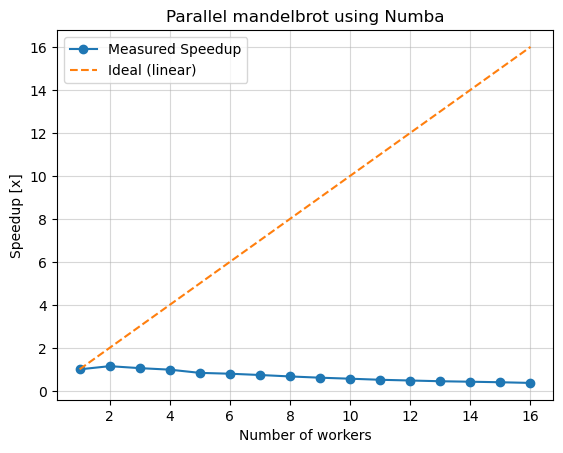

In [27]:
m3_results = pd.read_csv(m3_file)

workers = m3_results["total_workers"]
speedups = m3_results["speedup"]

ideal = range(1, len(speedups)+1)

plt.plot(workers, speedups, marker="o", label="Measured Speedup")
plt.plot(ideal, ideal, linestyle="--", label="Ideal (linear)")
plt.ylabel("Speedup [x]")
plt.xlabel("Number of workers")
plt.grid(alpha=0.5)
plt.legend()
plt.title("Parallel mandelbrot using chunks")
plt.show()

- **Back-solve implied $s = \frac{1/S_p^∗ − 1/p^*}{1 − 1/p^*}$**

In [28]:
speedups = list(speedups)

s_max = max(speedups)
p_star = speedups.index(s_max) + 1

s =  (1/s_max - 1/p_star) / (1 - 1/p_star)

print(f"Maximum speedup of {s_max:.2f}x achieved using {p_star} workers")
print(f"Back-solved: Approximately {s*100:.2f}% is serial.")

Maximum speedup of 1.15x achieved using 2 workers
Back-solved: Approximately 74.24% is serial.


- **Is your $s$ smaller than your L04 result?** - Better load balance ⇒ lower apparent $s$?

In lecture 4, we were only asked to backed-solve in *exercise* 3, question 3, which were about $\pi$ estimation and not mandelbrot set. Thus, I am unable to make a comparison.

#### ****3. Brief recommendation:****

- **What settings give the best time?**

The best parallel-chunked settings were achieved with just 2 workers.

- **Is parallelisation worth it on your hardware?** - Compare speedup and LIF to your serial
Numba baseline

Based on the speedup from the parallel chunked implementation, it is a clearly not worthwhile. Using just plain serial (precompiled) Numba is *way* faster.

*Comparing*: Speedup

$$\text{Speedup} = \frac{T_{\text{NumbaSerial}}}{T_{\text{ParallelChunked}}} = \frac{0.048 \text{s}}{0.269 \text{s}} = 0.18\times$$

$$\text{Slowdown} = \frac{T_{\text{ParallelChunked}}}{T_{\text{NumbaSerial}}} = \frac{0.269 \text{s}}{0.048 \text{s}} = 5.60\times$$

*Comparing*: LIF
$$ T_1 = 0.048 \text{s} \tag{Numba Baseline} $$

$$ T_p = T_{\text{ParallelChunked}} = 0.269 \text{s} $$

$$ p = 16 \tag{\text{os.cpu\_count()} }$$

$$\text{LIF} = \frac{p \cdot T_p}{T_1} - 1 = \frac{16 \cdot 0.269 \text{s}}{0.048 \text{s}} - 1 = 88.67\times $$

- **Write 2–3 sentences in your performance notebook**

Computing the mandelbrot set using Python's multiprocessing `Pool` combined with chunked tasks has proven to be a rather poor combination, resulting in *massive* overhead, as indicated by the Load Imbalance Factor (LIF) of $89\times$. Back-solving suggests that approximately $72\%$ of the workload behaves serially, likely  due to inter-process communication (IPC) overhead when scattering and gathering results. In fact, comparing this to Numba serial implementation resulted in a slowdown of $5.60\times$.

#### ****4. Submit to Performance Tracker:****

- **Enter your best multiprocessing time on Moodle - (1024×1024, Implementation: “Multiprocessing”)**

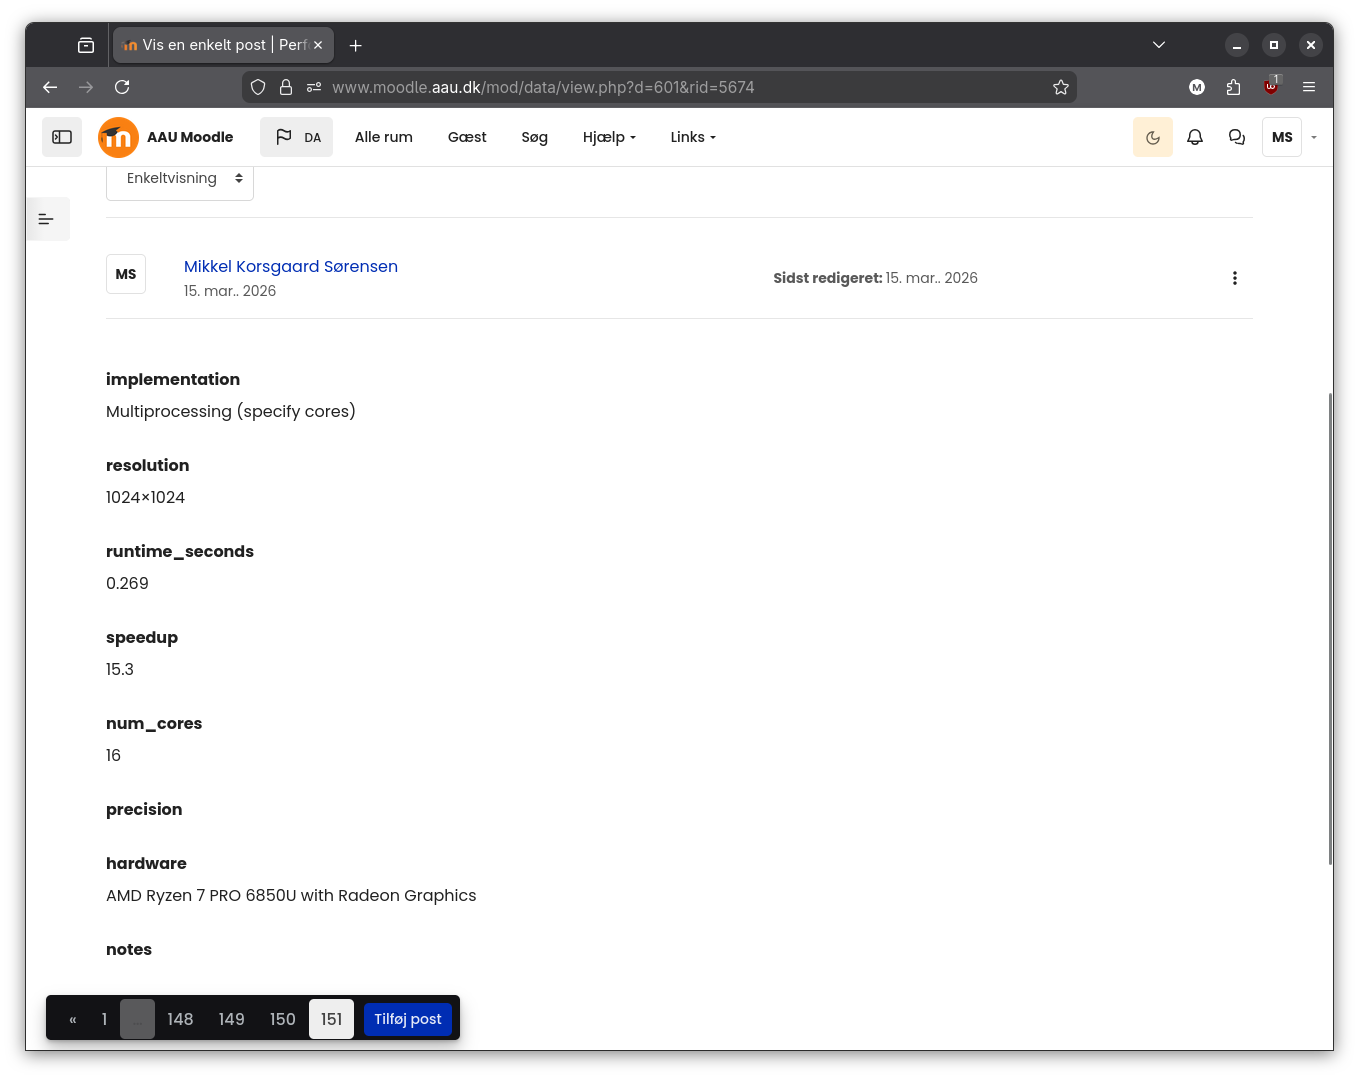

****Done?** Record all results in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit a8a32a5487c0c369f12222e9e324777cb2e74ee5 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 20:49:33 2026 +0000

    l05: milestone 3 done
```